In [3]:
import pandas as pd
import numpy as np
import time
import os

print("📂 Cargando dataset original...")
# 1. Cargar el dataset crudo indicando explícitamente el separador ';'
df = pd.read_csv('../Bases de datos/Dataset_ECD_100R.csv', sep=';')

# --- CONFIGURACIÓN DEL ESPECTRO ---
wl_nm = np.linspace(150, 600, 100)


# 2. Generar listas de columnas exactas para evitar desórdenes
cols_hammett = [f'Pos_{i}' for i in range(1, 17)]
cols_R = [f'R_{i}' for i in range(1, 101)]
cols_wl = [f'nm_{i}' for i in range(1, 101)]

print(f"📊 Encontradas {len(cols_hammett)} posiciones y {len(cols_wl)} transiciones exactas.")

# 3. Función vectorizada para calcular la envolvente
def calcular_envolvente(wl_transitions, r_transitions, wl_grid,
                        sigma_ev=0.2, HC_EV_NM=1240.0):
    espectro = np.zeros_like(wl_grid)
    valid_idx = ~np.isnan(wl_transitions) & ~np.isnan(r_transitions)
    
    for wl_t, r_t in zip(wl_transitions[valid_idx], r_transitions[valid_idx]):
        sigma_nm = (wl_t**2 / HC_EV_NM) * sigma_ev + 1e-5
        espectro += r_t * np.exp(-((wl_grid - wl_t)**2) / (2 * sigma_nm**2))
    return espectro
# 4. Procesar todas las moléculas
print("⚙️ Calculando envolventes para todas las moléculas...")
start_time = time.time()

S_real_list = []
for index, row in df.iterrows():
    # Extraemos los valores como floats (importante por si Pandas lee algún string vacío)
    wl_trans = row[cols_wl].values.astype(float)
    r_trans = row[cols_R].values.astype(float)
    
    espectro = calcular_envolvente(wl_trans, r_trans, wl_nm)
    S_real_list.append(espectro)

S_real_matrix = np.array(S_real_list) # Matriz de tamaño (N_moleculas, 100)
X_hammett = df[cols_hammett].values   # Matriz de entradas X

print(f"✅ Cálculo completado en {time.time() - start_time:.2f} segundos.")

# ====================================================================
# 5. ALINEACIÓN CON LA BASE DE DATOS DE 6 PARÁMETROS
# ====================================================================
print("\n🔄 Iniciando alineación estricta con la base de 6 parámetros...")
archivo_6_parametros = '../Bases de datos/DatasetDefinitivo_2310indep.csv' 
df_6p = pd.read_csv(archivo_6_parametros, sep=',') # Sep por comas según tu lista

# Análisis de conjuntos
mols_100 = set(df['Molecula'])
mols_6p = set(df_6p['Molecula'])

mols_comunes = mols_100.intersection(mols_6p)
mols_solo_en_100 = mols_100 - mols_6p
mols_solo_en_6p = mols_6p - mols_100

print(f"📊 Moléculas en memoria (100 pts): {len(mols_100)}")
print(f"📊 Moléculas en dataset 6 pts: {len(mols_6p)}")
print(f"🔗 Moléculas comunes a ambos: {len(mols_comunes)}\n")

if mols_solo_en_100:
    print(f"⚠️ AVISO: {len(mols_solo_en_100)} moléculas en memoria NO están en el dataset de 6 y se DESECHARÁN.")
if mols_solo_en_6p:
    print(f"⚠️ AVISO: {len(mols_solo_en_6p)} moléculas en el dataset de 6 NO están en memoria y se IGNORARÁN.")

# Filtrado de DataFrame y matrices para quedarnos solo con las comunes
mascara_comunes = df['Molecula'].isin(mols_comunes)
df_filtrado = df[mascara_comunes].reset_index(drop=True)

X_hammett_final = X_hammett[mascara_comunes]
S_real_matrix_final = S_real_matrix[mascara_comunes]

# Cruce para extraer los 6 parámetros en el mismo orden exacto
df_alineado = pd.merge(df_filtrado, df_6p, on='Molecula', how='left')
columnas_base = ['Rmax', 'nm_Rmax', 'Rmin', 'nm_Rmin', 'R1', 'nm_R1']
base_6_params = df_alineado[columnas_base].values

# ====================================================================
# 6. GUARDADO FINAL SINCRONIZADO
# ====================================================================
print("\n💾 Guardando todas las bases de datos sincronizadas...")

ruta_guardado = '../Bases de datos/PINN 100'
os.makedirs(ruta_guardado, exist_ok=True)

np.save(f'{ruta_guardado}/X_hammett.npy', X_hammett_final)
np.save(f'{ruta_guardado}/Y_espectros_150_600.npy', S_real_matrix_final)
np.save(f'{ruta_guardado}/wl_nm_150_600.npy', wl_nm)
np.save(f'{ruta_guardado}/Y_base_6puntos.npy', base_6_params)

print(f"✅ ¡Base de datos guardada con éxito en la carpeta '{ruta_guardado}'!")
print(f"Dimensión final X (Hammett): {X_hammett_final.shape}")
print(f"Dimensión final Y (Espectros 100 pt): {S_real_matrix_final.shape}")
print(f"Dimensión final Y_base (6 pt): {base_6_params.shape}")

📂 Cargando dataset original...


📊 Encontradas 16 posiciones y 100 transiciones exactas.
⚙️ Calculando envolventes para todas las moléculas...
✅ Cálculo completado en 35.34 segundos.

🔄 Iniciando alineación estricta con la base de 6 parámetros...
📊 Moléculas en memoria (100 pts): 12407
📊 Moléculas en dataset 6 pts: 12449
🔗 Moléculas comunes a ambos: 12407

⚠️ AVISO: 42 moléculas en el dataset de 6 NO están en memoria y se IGNORARÁN.

💾 Guardando todas las bases de datos sincronizadas...
✅ ¡Base de datos guardada con éxito en la carpeta '../Bases de datos/PINN 100'!
Dimensión final X (Hammett): (12407, 16)
Dimensión final Y (Espectros 100 pt): (12407, 100)
Dimensión final Y_base (6 pt): (13120, 6)


🔄 Cargando matrices sincronizadas...
✅ Cargados 12407 espectros para comparación.
⚙️ Generando envolventes de 3 transiciones para toda la base de datos...
📊 Calculando métricas de similitud...


,MAE,MSE,RMSE,R²,Coseno,IAD (Integral)
100 Trans vs 3 Trans,78.0517,17403.1455,125.9542,0.2301,0.6301,7849.6197


🎨 Generando gráficas comparativas...


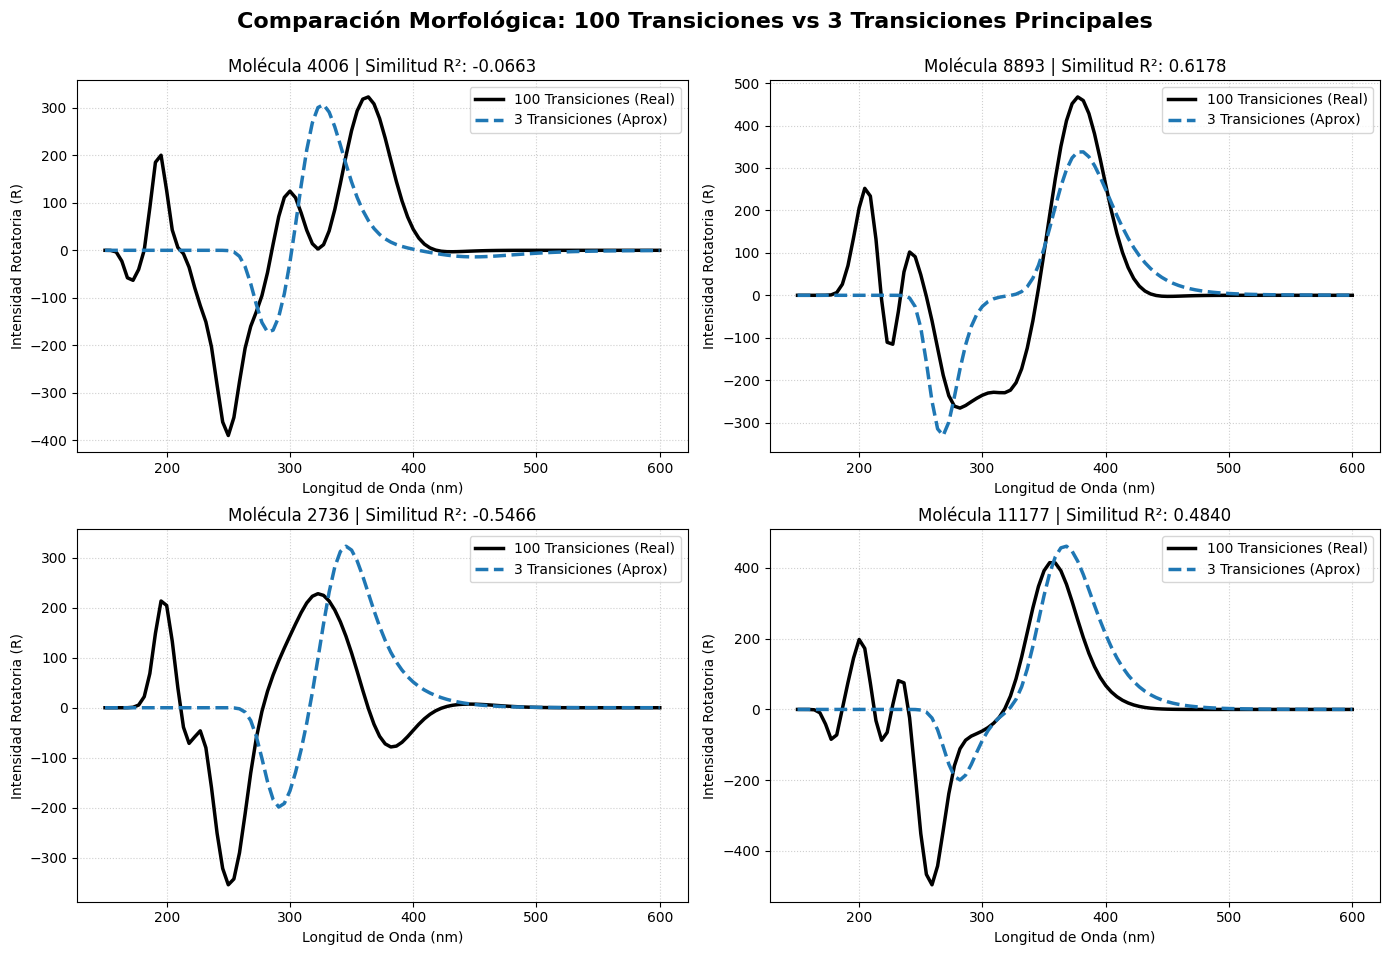

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.integrate import trapezoid
import random

print("🔄 Cargando matrices sincronizadas...")
ruta_guardado = '../Bases de datos/PINN 100'

# 1. Cargamos los datos que ya están perfectamente alineados
S_100 = np.load(f'{ruta_guardado}/Y_espectros_150_600.npy')
params_3t = np.load(f'{ruta_guardado}/Y_base_6puntos.npy') # [Rmax, nm_Rmax, Rmin, nm_Rmin, R1, nm_R1]
wl_nm = np.load(f'{ruta_guardado}/wl_nm_150_600.npy')
SIGMA_EV = 0.2
HC_EV_NM = 1240.0

print(f"✅ Cargados {len(S_100)} espectros para comparación.")

# ====================================================================
# 2. RECONSTRUCCIÓN DE LA ENVOLVENTE DE 3 TRANSICIONES
# ====================================================================
def calcular_envolvente_3t(params, wl):
    """Calcula la envolvente sumando solo las 3 transiciones principales."""
    S = np.zeros_like(wl)
    # params tiene el orden: Rmax, nm_max, Rmin, nm_min, R1, nm_1
    for i in range(0, 6, 2):
        R = params[i]
        nm = params[i+1]
        sigma = (wl**2 / HC_EV_NM) * SIGMA_EV + 1e-5
        S += R * np.exp(-((wl - nm)**2) / (2 * sigma**2))
    return S

print("⚙️ Generando envolventes de 3 transiciones para toda la base de datos...")
S_3t = np.array([calcular_envolvente_3t(p, wl_nm) for p in params_3t])

# ====================================================================
# 3. CÁLCULO DE MÉTRICAS GLOBALES (100 transiciones vs 3 transiciones)
# ====================================================================
print("📊 Calculando métricas de similitud...")

metricas = []
for i in range(len(S_100)):
    y_true = S_100[i] # Consideramos el de 100 como la "verdad absoluta"
    y_pred = S_3t[i]  # Consideramos el de 3 como la "aproximación"
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    dot_product = np.dot(y_true, y_pred)
    norm_true = np.linalg.norm(y_true)
    norm_pred = np.linalg.norm(y_pred)
    coseno = dot_product / (norm_true * norm_pred) if (norm_true * norm_pred) != 0 else 0
    
    iad = np.abs(trapezoid(y_true, wl_nm) - trapezoid(y_pred, wl_nm))
    
    metricas.append([mae, mse, rmse, r2, coseno, iad])

# Calculamos la media de todas las moléculas
medias = np.mean(metricas, axis=0)

df_metricas = pd.DataFrame([medias], columns=["MAE", "MSE", "RMSE", "R²", "Coseno", "IAD (Integral)"])
df_metricas.index = ["100 Trans vs 3 Trans"]
display(df_metricas.style.format("{:.4f}").background_gradient(cmap='Blues'))

# ====================================================================
# 4. VISUALIZACIÓN DE EJEMPLOS
# ====================================================================
print("🎨 Generando gráficas comparativas...")

num_ejemplos = 4
indices_aleatorios = random.sample(range(len(S_100)), num_ejemplos)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación Morfológica: 100 Transiciones vs 3 Transiciones Principales', 
             fontsize=16, fontweight='bold', y=0.95)

axes = axes.flatten()

for i, idx in enumerate(indices_aleatorios):
    ax = axes[i]
    
    y_100 = S_100[idx]
    y_3 = S_3t[idx]
    
    # R2 individual para ese recuadro
    r2_indiv = r2_score(y_100, y_3)
    
    ax.plot(wl_nm, y_100, label='100 Transiciones (Real)', color='black', linewidth=2.5)
    ax.plot(wl_nm, y_3, label='3 Transiciones (Aprox)', color='#1f77b4', linestyle='--', linewidth=2.5)
    
    ax.set_title(f'Molécula {idx} | Similitud R²: {r2_indiv:.4f}', fontsize=12)
    ax.set_xlabel('Longitud de Onda (nm)')
    ax.set_ylabel('Intensidad Rotatoria (R)')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
fig.subplots_adjust(top=0.88)
plt.show()